In [1]:
from src import *
from scipy.stats import norm

In [2]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb, physics, microtype}'

# 相同信噪比 性能相同

In [8]:
di_vars = [LoadEstimates(rf'data/noisy/di_5px_f0.2_d{d}.npz').estimates.var() for d in range(0, 101, 2)]
spade_vars = [LoadEstimates(rf'data/noisy/spade_5px_f0.2_d{d}.npz').estimates.var() for d in range(0, 101, 2)]


di_x = np.load(r'result/expt/noisy/di_5px.npz')['b']
spade_x = np.load(r'result/expt/noisy/spade_5px.npz')['b']

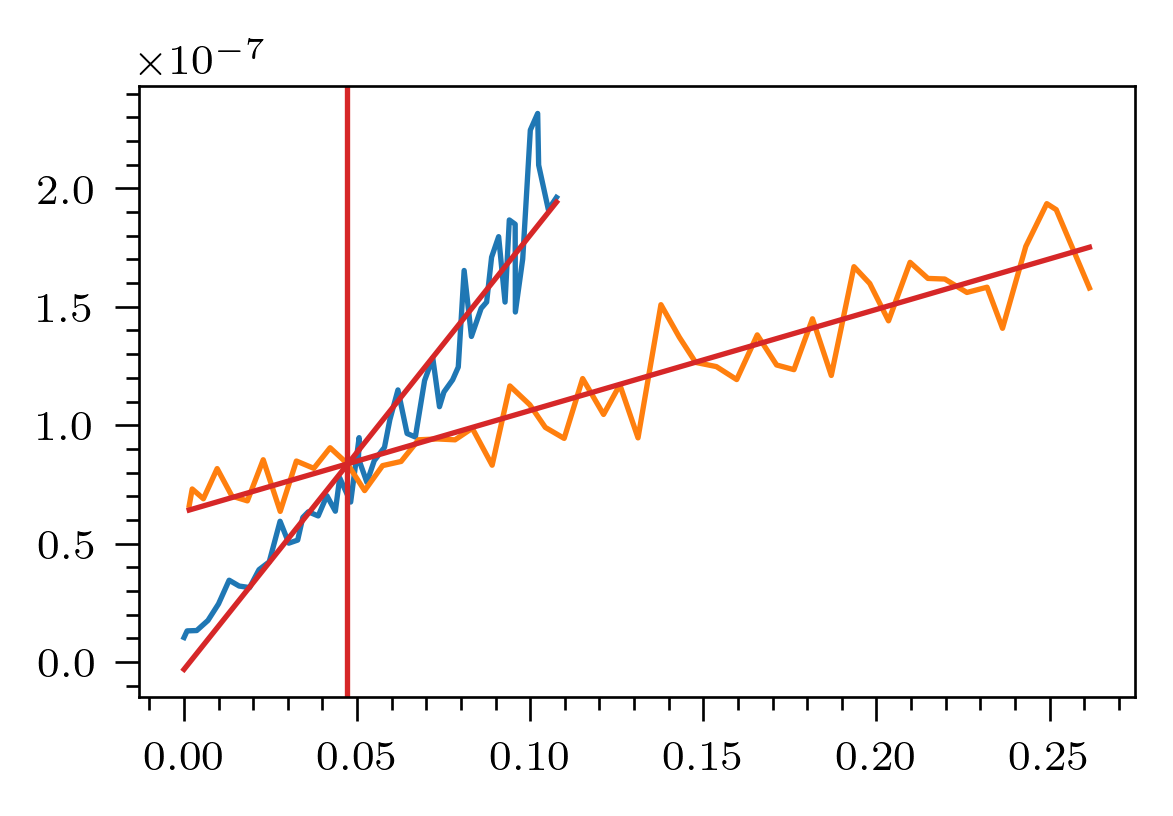

In [10]:
plt.plot(di_x, di_vars)
plt.plot(di_x, np.poly1d(np.polyfit(np.ravel(di_x), np.ravel(di_vars), 1))(di_x), 'tab:red')

plt.plot(spade_x, spade_vars)
plt.plot(spade_x, np.poly1d(np.polyfit(np.ravel(spade_x), np.ravel(spade_vars), 1))(spade_x), 'tab:red')

plt.axvline(0.047, color='tab:red')
plt.show()

In [3]:
spade_c = LoadEstimates('data/noisy/spade_5px_f0.2_d22.npz')
di_c = LoadEstimates('data/noisy/di_5px_f0.2_d38.npz')

In [4]:
spade_b = np.round(spade_c.background / spade_c.photons, 3)
di_b = np.round(di_c.background / di_c.photons, 3)

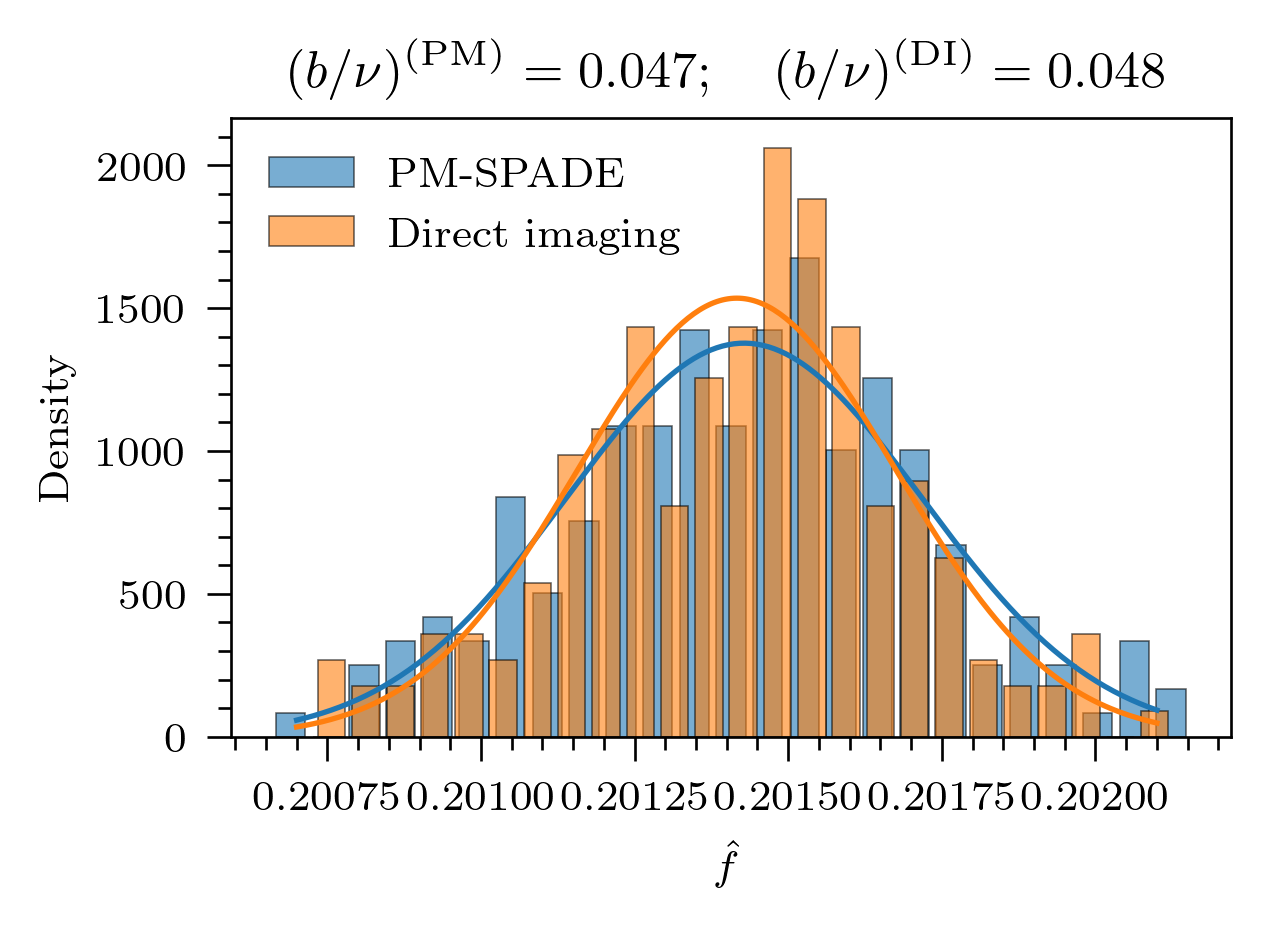

In [16]:
plt.figure(figsize=(8.5/2.54, 8.5/2.54))

plt.hist(spade_c.estimates, bins=25, edgecolor='black', linewidth=0.3, align='mid', rwidth=0.8, alpha=0.6, density=True, label='PM-SPADE')
plt.hist(di_c.estimates, bins=25, edgecolor='black', linewidth=0.3, align='mid', rwidth=0.8, alpha=0.6, density=True, label='Direct imaging')


x_axis = np.linspace(0.2007, 0.2021, 300)
plt.plot(x_axis, norm(spade_c.estimates.mean(), spade_c.estimates.std()).pdf(x_axis), alpha=1, color='tab:blue')
plt.plot(x_axis, norm(di_c.estimates.mean(), di_c.estimates.std()).pdf(x_axis), alpha=1, color='tab:orange')


plt.legend(frameon=False)

plt.title(r'$(b/\nu)^\text{(PM)}'+ f' = {spade_b};\quad' + r'(b/\nu)^\text{(DI)}'+ f' = {di_b}$')
plt.xlabel(r'$\hat f$')
plt.ylabel(r'$\rm Density$')

plt.gca().set_box_aspect(0.618)
plt.tight_layout()
plt.show()

# 相同噪声 无交点

In [13]:
di_vars = [LoadEstimates(rf'data/noisy/di_5px_f0.2_d{d}.npz').estimates.var() for d in range(0, 101, 2)]
spade_vars = [LoadEstimates(rf'data/noisy/spade_5px_f0.2_d{d}.npz').estimates.var() for d in range(0, 101, 2)]


di_x = [LoadEstimates(rf'data/noisy/di_5px_f0.2_d{d}.npz').background for d in range(0, 101, 2)]
spade_x = [LoadEstimates(rf'data/noisy/spade_5px_f0.2_d{d}.npz').background for d in range(0, 101, 2)]

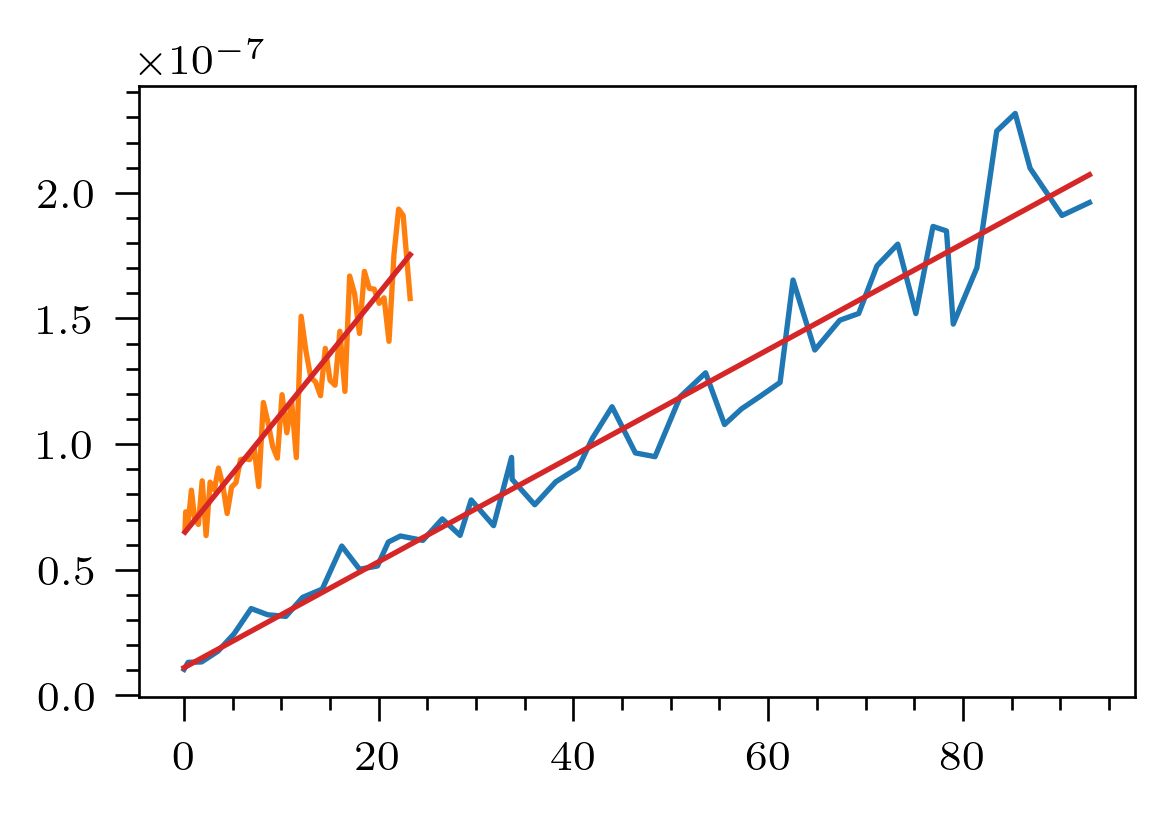

In [15]:
plt.plot(di_x, di_vars)
plt.plot(di_x, np.poly1d(np.polyfit(np.ravel(di_x), np.ravel(di_vars), 1))(di_x), 'tab:red')

plt.plot(spade_x, spade_vars)
plt.plot(spade_x, np.poly1d(np.polyfit(np.ravel(spade_x), np.ravel(spade_vars), 1))(spade_x), 'tab:red')

# plt.axvline(0.047, color='tab:red')
plt.show()